In [18]:
from nilearn import datasets, plotting, image, masking, maskers
from sklearn.decomposition import PCA

In [19]:
dataset = datasets.fetch_development_fmri(n_subjects=1) #Fetch dataset
images = dataset['func'][0] #Retrieve the list of brain images

C:\Users\Andrew\AppData\Roaming\Python\Python39\site-packages\nilearn\plotting\html_stat_map.py:112: UserWarning: Threshold given was 1e-06, but the data has no values below -116.0191650390625. 
  warnings.warn("Threshold given was {0}, but "



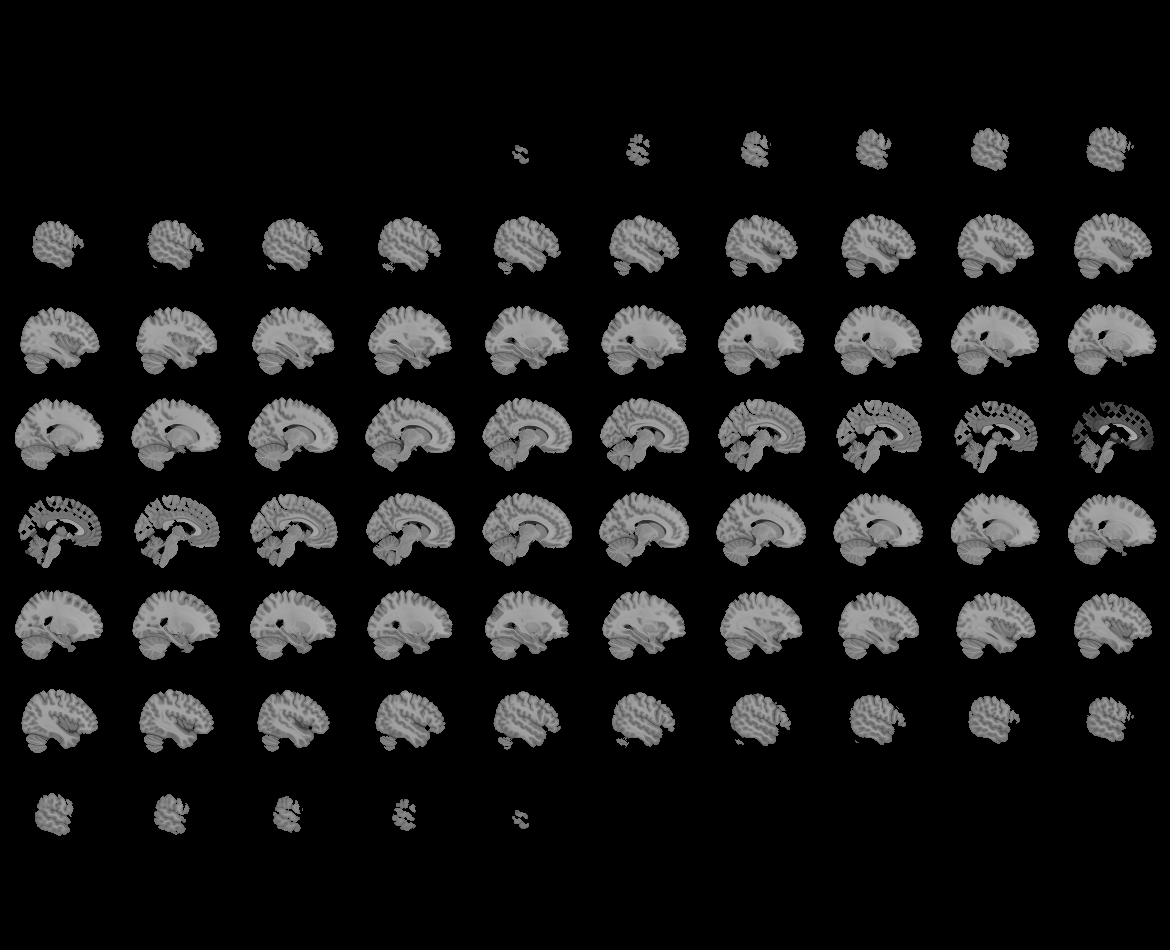
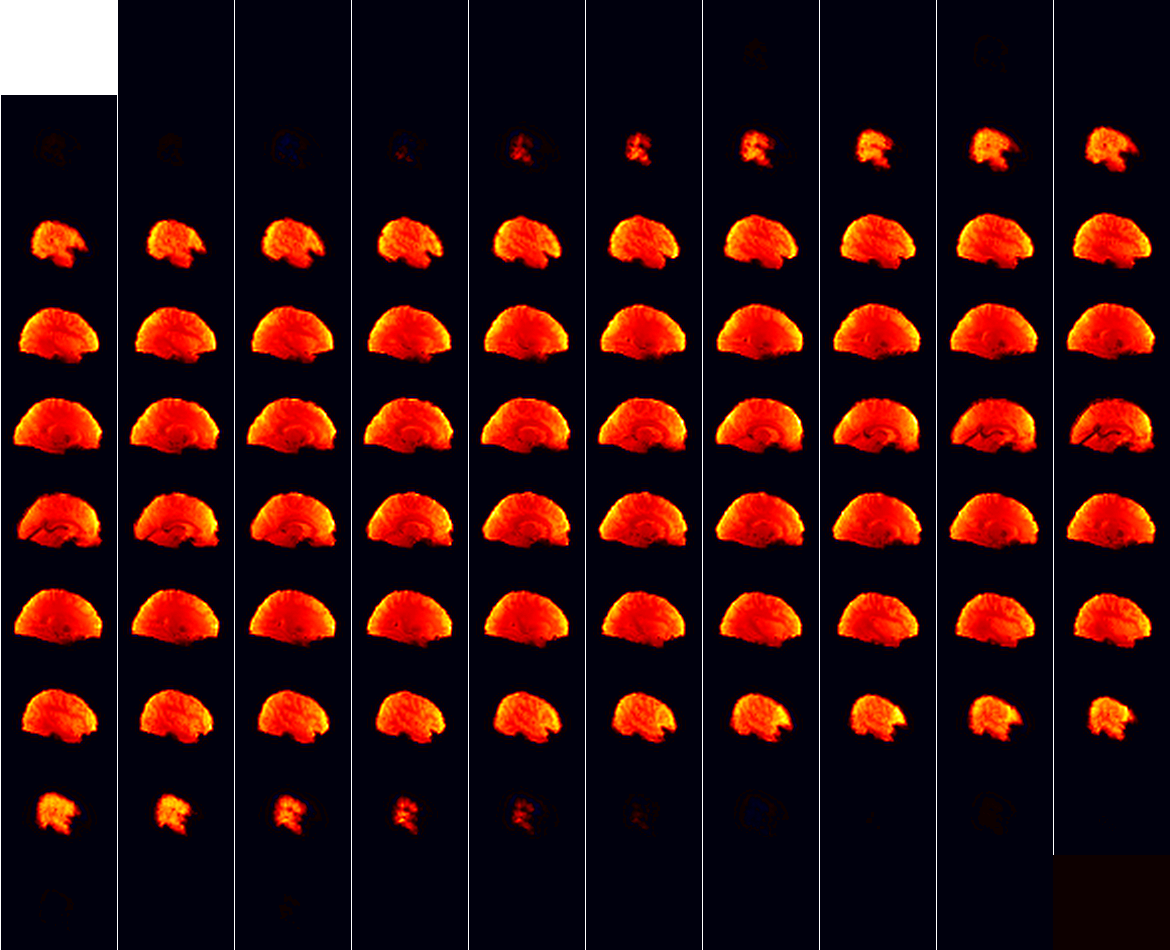

In [20]:
#Display the data averaged out over all the samples
avg_img = image.mean_img(images)
plotting.view_img(avg_img)

In [21]:
mask = masking.compute_epi_mask(avg_img) #Compute the mask

In [22]:
nm = maskers.NiftiMasker(mask_img=mask) #Using the mask, convert the fetched data into a 
X = nm.fit_transform(dataset['func'][0]) #2D array (samples, features) This is termed "masking"

In [23]:
print(X.shape)

(168, 24256)


In [24]:
pca = PCA(n_components=5) #Intialize a new PCA object. We seek the top five orthogonal vectors that maximize variance

In [25]:
result = pca.fit_transform(X) #Perform PCA on our data

In [26]:
print(pca.explained_variance_ratio_) #Examine how much variance each principal component captured

[0.14763752 0.0699939  0.05985376 0.05132633 0.04426073]
